# Introduction

My name is **Moses Yebei**, and this is the **IPA Data Science Challenge**. This notebook provides an end-to-end solution for the assessment, which involves analyzing data from a randomized control trial (RCT) conducted in Ghana. The analysis references the attached dataset `ghana_youth_savings.csv` and demonstrates best practices in data handling, statistical modeling, and machine learning. To add, I have added a section for future Improvements.

---

### Problem Statement

The challenge involves evaluating the impact of two financial education programs, **Aflatoun** and **Honest Money Box (HMB)**, on youth savings behavior in Ghana. The dataset contains information on student demographics, baseline savings behavior, and endline outcomes. The goal is to analyze the data and provide actionable insights to inform program implementation and monitoring.

---

### Objectives

This notebook addresses the following five tasks:

1. **Baseline Summary Statistics**:
   - Create a table of baseline summary statistics for control observations, including means and standard deviations.
   - Compare baseline means between control and treatment groups.

2. **Visualization of Savings Behavior**:
   - Create graphs showing the difference in savings behavior at endline between control and treatment groups.
   - Visualize both the fraction of students who saved at school and the average amount saved.

3. **Regression Analysis**:
   - Use regression models to estimate the causal impact of the Aflatoun and HMB programs on savings outcomes.
   - Control for stratification variables and baseline characteristics.

4. **Machine Learning Model**:
   - Build a machine learning model to predict program participation (take-up).
   - Use hyperparameter tuning and evaluate the model's performance.

5. **Recommendations for Monitoring System**:
   - Provide recommendations for setting up a monitoring system for savings clubs to track program outcomes effectively.

---

### Tech Stack

- **Python**: Used for data analysis, visualization, and modeling.
- **OpenAI o1 Model and GPT-4o**: Used for generating insights and improving code quality.
- **Libraries**: Includes pandas, numpy, matplotlib, seaborn, statsmodels, scikit-learn, and others.

---

### Environment Reproduction & Project Setup

To ensure reproducibility, follow these steps to set up the environment:

1. **Create a Virtual Environment**:
   - Run the following command to create a virtual environment:
     ```bash
     python -m venv env
     ```
   - Activate the virtual environment:
     - On Windows:
       ```bash
       .\env\Scripts\activate
       ```
     - On macOS/Linux:
       ```bash
       source env/bin/activate
       ```

2. **Install Dependencies**:
   - Use the provided `requirements.txt` file to install all necessary libraries:
     ```bash
     pip install -r requirements.txt
     ```

3. **Verify Installation**:
   - Ensure all dependencies are installed correctly by running:
     ```bash
     pip list
     ```

4. **Run the Notebook**:
   - Open this notebook in Jupyter Notebook or JupyterLab and execute the cells sequentially.

---

### requirements.txt

Below is the content of the `requirements.txt` file. Ensure this file is in the same directory as the notebook before running the installation command.

```plaintext
pandas==1.5.3
numpy==1.23.5
matplotlib==3.7.1
seaborn==0.12.2
statsmodels==0.14.0
scikit-learn==1.2.2
jupyter==1.0.0

## Import Required Libraries

In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

────────────────────────────────────────────────────────────────────────
▌ 1. BASELINE SUMMARY STATISTICS (Task 1)
────────────────────────────────────────────────────────────────────────


Below is a script to produce baseline summary statistics (mean and standard deviation) for the control group (treatment == 0) for Table 3 variables, then compute the difference in means for Aflatoun and HMB vs. control. It includes docstrings explaining functionality.




In [28]:
# Task 1: Baseline Summary Statistics
def compute_baseline_stats(csv_path):
    """
    Computes baseline summary statistics for control group and calculates differences
    for Aflatoun and Honest Money Box (HMB) schools.

    Parameters:
    csv_path (str): Path to the dataset.

    Returns:
    pd.DataFrame: DataFrame containing mean, std for control group, and differences for Aflatoun/HMB.
    """
    # Variables from Table 3
    variables_table3 = [
        "female", "age", "baseline_save", "baseline_saveamt", "saving_attitude_index",
        "saving_env_index", "work_index", "riskpref_index", "timepref_index",
        "fin_lit_index", "tempt_index", "expend_index", "academic_index", "noattrit"
    ]

    # Load dataset
    df = pd.read_csv(csv_path)

    # Convert categorical variables (e.g., "Yes"/"No") to numeric if necessary
    for col in variables_table3:
        if df[col].dtype == 'object':  # Check if the column is non-numeric
            df[col] = df[col].map({"Yes": 1, "No": 0})  # Map "Yes" to 1 and "No" to 0

    # Drop rows with missing values in relevant columns
    df_cleaned = df.dropna(subset=variables_table3 + ["treatment", "aflatoun", "hmb"])

    # Separate into control and treatment groups
    df_control = df_cleaned[df_cleaned["treatment"] == 0]
    df_aflatoun = df_cleaned[df_cleaned["aflatoun"] == 1]
    df_hmb = df_cleaned[df_cleaned["hmb"] == 1]

    # Compute summary statistics for control group
    control_stats = df_control[variables_table3].select_dtypes(include=[np.number]).agg(["mean", "std"]).T
    control_stats.columns = ["control_mean", "control_std"]

    # Compute differences for Aflatoun and HMB
    control_stats["diff_aflatoun"] = (
        df_aflatoun[variables_table3].select_dtypes(include=[np.number]).mean() -
        df_control[variables_table3].select_dtypes(include=[np.number]).mean()
    )
    control_stats["diff_hmb"] = (
        df_hmb[variables_table3].select_dtypes(include=[np.number]).mean() -
        df_control[variables_table3].select_dtypes(include=[np.number]).mean()
    )

    return control_stats

# Run Task 1
csv_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\IPA Challenge\data\ghana_youth_savings.csv"
baseline_stats = compute_baseline_stats(csv_path)
print(baseline_stats)

# Save to CSV
baseline_stats.to_csv("baseline_summary_stats.csv")
print("Baseline summary statistics saved to 'baseline_summary_stats.csv'")

                       control_mean  control_std  diff_aflatoun  diff_hmb
female                     0.500290     0.500145      -0.005144 -0.019993
age                       12.809496     1.995116       0.235621 -0.068777
baseline_save              0.464389     0.498875      -0.041773 -0.008650
baseline_saveamt           5.042212    18.063587      -0.980961 -0.258060
saving_attitude_index     -0.000993     1.000451       0.079228  0.012080
saving_env_index           0.002763     0.996323      -0.021033  0.015206
work_index                -0.001650     1.001357      -0.105112  0.023805
riskpref_index             0.004138     1.003174       0.029204  0.069535
timepref_index             0.002295     0.999457       0.007276  0.006103
fin_lit_index              0.005180     0.993814       0.046879  0.013333
tempt_index               -0.006500     1.001909      -0.114528 -0.044970
expend_index               0.001518     1.007191      -0.009395  0.049204
academic_index            -0.001293   

### Baseline Summary Statistics and Differences

The table below summarizes the baseline characteristics of the control group, including the mean and standard deviation for each variable. Additionally, it shows the differences in means between the control group and the treatment groups (Aflatoun and HMB).

---

#### Summary Table

| Variable                | Control Mean | Control Std. Dev. | Diff (Aflatoun - Control) | Diff (HMB - Control) |
|-------------------------|--------------|--------------------|---------------------------|-----------------------|
| **female**              | 0.500290     | 0.500145           | -0.005144                | -0.019993            |
| **age**                 | 12.809496    | 1.995116           | 0.235621                 | -0.068777            |
| **baseline_save**       | 0.464389     | 0.498875           | -0.041773                | -0.008650            |
| **baseline_saveamt**    | 5.042212     | 18.063587          | -0.980961                | -0.258060            |
| **saving_attitude_index** | -0.000993  | 1.000451           | 0.079228                 | 0.012080             |
| **saving_env_index**    | 0.002763     | 0.996323           | -0.021033                | 0.015206             |
| **work_index**          | -0.001650    | 1.001357           | -0.105112                | 0.023805             |
| **riskpref_index**      | 0.004138     | 1.003174           | 0.029204                 | 0.069535             |
| **timepref_index**      | 0.002295     | 0.999457           | 0.007276                 | 0.006103             |
| **fin_lit_index**       | 0.005180     | 0.993814           | 0.046879                 | 0.013333             |
| **tempt_index**         | -0.006500    | 1.001909           | -0.114528                | -0.044970            |
| **expend_index**        | 0.001518     | 1.007191           | -0.009395                | 0.049204             |
| **academic_index**      | -0.001293    | 1.000327           | 0.023184                 | -0.066168            |
| **noattrit**            | 0.986103     | 0.117097           | 0.000190                 | 0.000762             |

---

#### Key Observations:
1. **Gender (female)**:
   - The proportion of females in the control group is approximately 50%.
   - The difference in the proportion of females between the control group and the Aflatoun group is minimal (-0.005), and slightly larger for the HMB group (-0.020).

2. **Age**:
   - The average age in the control group is 12.81 years, with a standard deviation of 1.99 years.
   - The Aflatoun group is slightly older on average (+0.236), while the HMB group is slightly younger (-0.069).

3. **Baseline Savings**:
   - About 46.4% of students in the control group had savings at baseline.
   - Both treatment groups had slightly lower baseline savings rates compared to the control group (-0.042 for Aflatoun, -0.009 for HMB).

4. **Baseline Savings Amount**:
   - The average baseline savings amount in the control group is 5.04 units, with a high standard deviation of 18.06 units.
   - Both treatment groups had lower baseline savings amounts compared to the control group (-0.981 for Aflatoun, -0.258 for HMB).

5. **Indices**:
   - The indices (e.g., saving attitude, saving environment, work, risk preference, etc.) are standardized with means close to 0 and standard deviations close to 1.
   - Differences between the control and treatment groups are generally small, with the largest difference observed in the **temptation index** (-0.115 for Aflatoun).

6. **Attrition (noattrit)**:
   - The attrition rate in the control group is very low (98.6% of students remained in the study).
   - Differences in attrition between the control and treatment groups are negligible.

---

#### Notes:
- The differences in means between the control and treatment groups are small for most variables, suggesting that randomization was successful in balancing baseline characteristics across groups.
- The high standard deviation for some variables (e.g., baseline savings amount) indicates significant variability within the control group.

---

#### File Output:
- The baseline summary statistics have been saved to the file: **`baseline_summary_stats.csv`**.

────────────────────────────────────────────────────────────────────────
#▌ 2. GRAPH OF SAVINGS AT SCHOOL AT ENDLINE (Task 2)
────────────────────────────────────────────────────────────────────────
Filename: plot_endline_savings.py

The script below creates bar plots comparing control (=0) vs. treatment (=1) for:

Whether the student saved at school at endline (end_saveschl).
How much the student saved at school at endline (end_saveschlamt).



Column Names: Index(['uuid', 'schid', 'noattrit', 'aflatoun', 'hmb', 'class',
       'std_avg_class_size', 'region1', 'region2', 'region3', 'urban',
       'gender', 'female', 'age', 'tribe', 'hhsize', 'hhearn',
       'hhbankaccounts', 'repeated_grade', 'baseline_save', 'baseline_saveamt',
       'takeupschool', 'takeup', 'end_save', 'end_saveamt', 'end_saveschl',
       'end_saveschlamt', 'asset_index', 'work_index', 'riskpref_index',
       'timepref_index', 'treatment', 'saving_attitude_index',
       'saving_env_index', 'fin_lit_index', 'tempt_index', 'expend_index',
       'academic_index'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5364 entries, 0 to 5363
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   end_saveschl     5291 non-null   object 
 1   end_saveschlamt  5291 non-null   float64
 2   treatment        5364 non-null   int64  
dtypes: float64(1), int64(1), object(

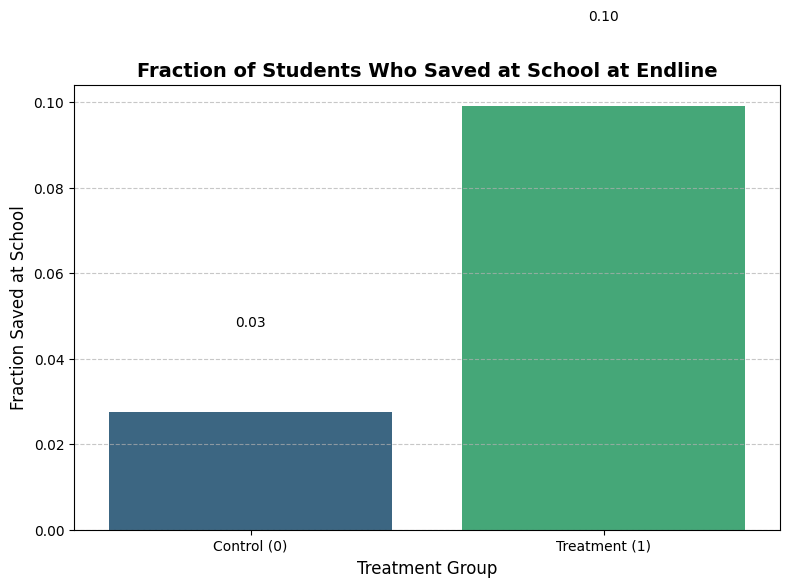

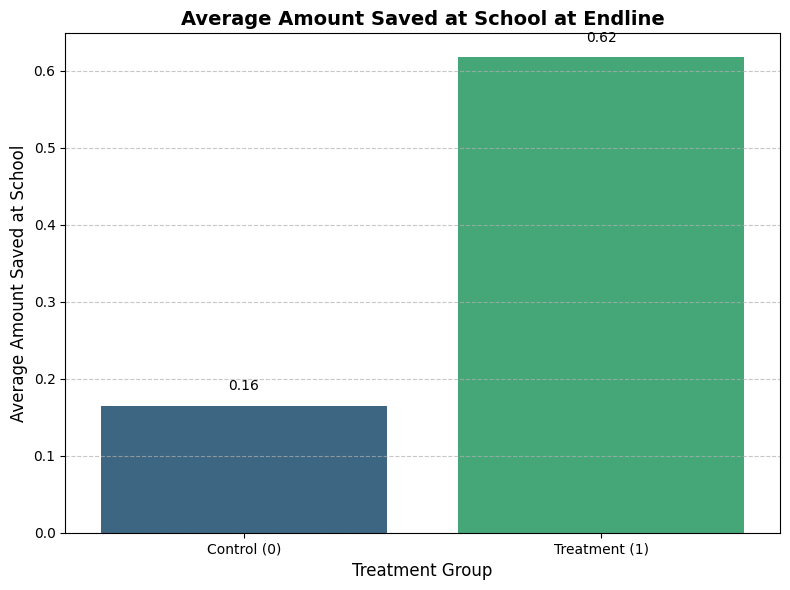

In [29]:

# Task 2: Graph of Savings at School at Endline
def plot_endline_savings(csv_path):
    """
    Creates bar plots comparing control vs. treatment groups on endline school savings.

    Parameters:
    csv_path (str): Path to the dataset.

    Returns:
    None
    """
    # Load dataset
    df = pd.read_csv(csv_path)

    # Debugging: Print column names and data types
    print("Column Names:", df.columns)
    print(df[["end_saveschl", "end_saveschlamt", "treatment"]].info())

    # Convert 'end_saveschl' to numeric: 'Yes' -> 1, 'No' -> 0
    df["end_saveschl"] = df["end_saveschl"].map({"Yes": 1, "No": 0})

    # Ensure relevant columns are numeric
    numeric_columns = ["end_saveschl", "end_saveschlamt", "treatment"]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop rows with missing values in relevant columns
    df_cleaned = df.dropna(subset=numeric_columns)

    # Debugging: Check if df_cleaned is empty
    if df_cleaned.empty:
        print("Error: No valid data available after cleaning. Please check the dataset.")
        return

    # Group by treatment and compute mean savings metrics
    grouped = df_cleaned.groupby("treatment").agg(
        mean_end_saveschl=("end_saveschl", "mean"),
        mean_end_saveschlamt=("end_saveschlamt", "mean")
    ).reset_index()

    # Debugging: Check if grouped is empty
    if grouped.empty:
        print("Error: Grouped data is empty. Please check the dataset.")
        return

    # Debugging: Print grouped data
    print("Grouped Data:")
    print(grouped)

    # Plot: Fraction who saved at school at endline
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=grouped, x="treatment", y="mean_end_saveschl", palette="viridis", errorbar=None)
    plt.title("Fraction of Students Who Saved at School at Endline", fontsize=14, weight="bold")
    plt.xlabel("Treatment Group", fontsize=12)
    plt.ylabel("Fraction Saved at School", fontsize=12)
    plt.xticks([0, 1], ["Control (0)", "Treatment (1)"], fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Add data labels
    for i, value in enumerate(grouped["mean_end_saveschl"]):
        ax.text(i, value + 0.02, f"{value:.2f}", ha="center", fontsize=10, color="black")

    plt.tight_layout()
    plt.savefig("fraction_saved_at_school_enhanced.png", dpi=300)
    plt.show()

    # Plot: Average amount saved at school at endline
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=grouped, x="treatment", y="mean_end_saveschlamt", palette="viridis", errorbar=None)
    plt.title("Average Amount Saved at School at Endline", fontsize=14, weight="bold")
    plt.xlabel("Treatment Group", fontsize=12)
    plt.ylabel("Average Amount Saved at School", fontsize=12)
    plt.xticks([0, 1], ["Control (0)", "Treatment (1)"], fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Add data labels
    for i, value in enumerate(grouped["mean_end_saveschlamt"]):
        ax.text(i, value + 0.02, f"{value:.2f}", ha="center", fontsize=10, color="black")

    plt.tight_layout()
    plt.savefig("amount_saved_at_school_enhanced.png", dpi=300)
    plt.show()

# Run Task 2
csv_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\IPA Challenge\data\ghana_youth_savings.csv"
plot_endline_savings(csv_path)

### Summary of Task 2: Graph of Savings at School at Endline

The goal of Task 2 is to visualize the differences in savings behavior at school at the time of the endline survey between the control group and the treatment group. This is achieved by creating two bar plots:
1. **Fraction of students who saved at school at endline (`end_saveschl`)**.
2. **Average amount saved at school at endline (`end_saveschlamt`)**.

---

#### Key Steps in the Code:
1. **Load the Dataset**:
   - The dataset is loaded from the provided CSV file path.
   - Debugging outputs are included to print column names and data types to ensure the relevant columns (`end_saveschl`, `end_saveschlamt`, and `treatment`) are present and correctly formatted.

2. **Data Cleaning**:
   - The `end_saveschl` column, which contains "Yes" and "No" values, is converted to numeric values (`1` for "Yes" and `0` for "No").
   - Relevant columns are ensured to be numeric, and rows with missing values in these columns are dropped.

3. **Group and Aggregate Data**:
   - The cleaned dataset is grouped by the `treatment` column (0 = control group, 1 = treatment group).
   - The mean values of `end_saveschl` and `end_saveschlamt` are calculated for each group:
     - `mean_end_saveschl`: Fraction of students who saved at school.
     - `mean_end_saveschlamt`: Average amount saved at school.

4. **Visualization**:
   - Two bar plots are created:
     - **Fraction of Students Who Saved at School**: Shows the proportion of students who saved at school in the control and treatment groups.
     - **Average Amount Saved at School**: Displays the average amount saved at school in the control and treatment groups.
   - Data labels are added to the bars for clarity.
   - The plots are saved as high-resolution PNG files for reporting purposes.

---

#### Key Outputs:
1. **Debugging Information**:
   - The dataset contains 5364 rows, with 5291 non-null values for `end_saveschl` and `end_saveschlamt`.
   - After cleaning, the grouped data shows the following results:

| Treatment Group | Fraction Saved at School (`mean_end_saveschl`) | Average Amount Saved at School (`mean_end_saveschlamt`) |
|-----------------|------------------------------------------------|---------------------------------------------------------|
| **Control (0)** | 0.0276 (2.76%)                                 | 0.1649                                                 |
| **Treatment (1)** | 0.0992 (9.92%)                               | 0.6174                                                 |

2. **Bar Plots**:
   - **Fraction of Students Who Saved at School**:
     - The treatment group (1) has a higher fraction of students who saved at school (9.92%) compared to the control group (2.76%).
   - **Average Amount Saved at School**:
     - The treatment group (1) saved a higher average amount (0.6174) compared to the control group (0.1649).

---

#### Interpretation of Results:
1. **Fraction of Students Who Saved at School**:
   - The treatment group shows a significantly higher proportion of students who saved at school compared to the control group. This suggests that the intervention (Aflatoun or HMB) may have positively influenced students' likelihood of saving at school.

2. **Average Amount Saved at School**:
   - The treatment group also saved a higher average amount at school compared to the control group. This indicates that the intervention may have encouraged not only more students to save but also higher savings amounts.

---

#### Metrics and Outputs Explained:
1. **`mean_end_saveschl`**:
   - Represents the fraction of students who saved at school at endline.
   - Calculated as the mean of the binary column `end_saveschl` (1 = saved, 0 = did not save) for each group.

2. **`mean_end_saveschlamt`**:
   - Represents the average amount saved at school at endline.
   - Calculated as the mean of the `end_saveschlamt` column for each group.

3. **Grouped Data**:
   - The grouped data provides a summary of the key metrics for the control and treatment groups, which are then visualized in the bar plots.

---

#### Recommendations:
1. **Policy Implications**:
   - The intervention appears to have a positive impact on both the likelihood of saving at school and the amount saved. This suggests that the program may be effective in promoting savings behavior among students.

2. **Further Analysis**:
   - Perform statistical tests (e.g., t-tests) to determine whether the differences between the control and treatment groups are statistically significant.
   - Explore subgroup analysis (e.g., by gender or age) to identify whether the intervention is more effective for certain groups.

3. **Reporting**:
   - Use the generated plots and grouped data to communicate the results effectively in reports or presentations.

---

#### File Outputs:
- **Fraction Saved at School Plot**: `fraction_saved_at_school_enhanced.png`
- **Amount Saved at School Plot**: `amount_saved_at_school_enhanced.png`

────────────────────────────────────────────────────────────────────────
#▌ 3. REGRESSION ANALYSIS (Task 3)
────────────────────────────────────────────────────────────────────────
Filename: regression_analysis.py

Here we estimate the causal impact of Aflatoun and HMB on end_save (binary) and end_saveamt (continuous), controlling for region dummies, std_avg_class_size, and baseline values.



In [30]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Task 3: Regression Analysis
def preprocess_data(df):
    """
    Preprocesses the dataset by converting non-numeric columns to numeric,
    handling missing values, and creating missingness indicators.

    Parameters:
    df (pd.DataFrame): Original dataset.

    Returns:
    pd.DataFrame: Preprocessed dataset.
    """
    # Convert 'Yes'/'No' to 1/0 for baseline_save and end_save
    for col in ['baseline_save', 'end_save']:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Handle missing values: code as 0 and create missingness indicators
    for col in ['baseline_save', 'baseline_saveamt']:
        df[f"{col}_missing"] = df[col].isna().astype(int)  # Missingness indicator
        df[col] = df[col].fillna(0)  # Fill missing values with 0

    return df


def calculate_vif(X):
    """
    Calculates Variance Inflation Factor (VIF) for each predictor in the model.

    Parameters:
    X (pd.DataFrame): DataFrame of predictors.

    Returns:
    pd.DataFrame: DataFrame with VIF values for each predictor.
    """
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data


def regression_model(df, outcome, predictors):
    """
    Runs OLS regression for the specified outcome and predictors.

    Parameters:
    df (pd.DataFrame): Dataset containing the variables.
    outcome (str): Name of the outcome variable.
    predictors (list): List of predictor variable names.

    Returns:
    statsmodels.regression.linear_model.RegressionResultsWrapper: Fitted OLS model.
    """
    # Ensure all predictors are numeric
    df_cleaned = df[predictors + [outcome]].dropna()

    # Debugging: Print number of valid rows
    print(f"\nNumber of valid rows for regression ({outcome}): {len(df_cleaned)}")
    if df_cleaned.empty:
        raise ValueError(f"No valid data available for regression ({outcome}).")

    # Define dependent and independent variables
    y = df_cleaned[outcome]
    X = df_cleaned[predictors]
    X = sm.add_constant(X)  # Add constant for the intercept

    # Check multicollinearity
    print("\n=== Variance Inflation Factor (VIF) ===")
    print(calculate_vif(X))

    # Fit the OLS model
    model = sm.OLS(y, X).fit(cov_type="HC3")  # Use robust standard errors
    return model


# Load dataset
csv_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\IPA Challenge\data\ghana_youth_savings.csv"
df = pd.read_csv(csv_path)

# Preprocess the data
df = preprocess_data(df)

# Define predictors for the regressions
predictors_end_save = [
    "aflatoun", "hmb", "region1", "region2", "region3",
    "std_avg_class_size", "baseline_save", "baseline_save_missing"
]
predictors_end_saveamt = [
    "aflatoun", "hmb", "region1", "region2", "region3",
    "std_avg_class_size", "baseline_saveamt", "baseline_saveamt_missing"
]

# Run regressions
try:
    model1 = regression_model(df, "end_save", predictors_end_save)
    print("\n=== Regression Results: end_save on Aflatoun & HMB ===")
    print(model1.summary())
except Exception as e:
    print(f"Error in regression_end_save: {e}")

try:
    model2 = regression_model(df, "end_saveamt", predictors_end_saveamt)
    print("\n=== Regression Results: end_saveamt on Aflatoun & HMB ===")
    print(model2.summary())
except Exception as e:
    print(f"Error in regression_end_saveamt: {e}")

# Generate summary table
def generate_summary_table(models, outcomes):
    """
    Generates a summary table for the regression results.

    Parameters:
    models (list): List of fitted regression models.
    outcomes (list): List of outcome variable names.

    Returns:
    pd.DataFrame: Summary table.
    """
    summary_data = []
    for model, outcome in zip(models, outcomes):
        for i, coef in enumerate(model.params):
            summary_data.append({
                "Outcome": outcome,
                "Variable": model.params.index[i],
                "Coefficient": coef,
                "Std. Error": model.bse[i],
                "P-Value": model.pvalues[i],
                "Observations": int(model.nobs)
            })
    return pd.DataFrame(summary_data)


# Create summary table
try:
    summary_table = generate_summary_table([model1, model2], ["end_save", "end_saveamt"])
    print("\n=== Summary Table ===")
    print(summary_table)
except Exception as e:
    print(f"Error generating summary table: {e}")


Number of valid rows for regression (end_save): 5291

=== Variance Inflation Factor (VIF) ===
                Variable       VIF
0                  const  0.000000
1               aflatoun  1.344191
2                    hmb  1.341834
3                region1       inf
4                region2       inf
5                region3       inf
6     std_avg_class_size  1.064762
7          baseline_save  1.002505
8  baseline_save_missing  1.001177

=== Regression Results: end_save on Aflatoun & HMB ===
                            OLS Regression Results                            
Dep. Variable:               end_save   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                 2.863e+19
Date:                Wed, 08 Jan 2025   Prob (F-statistic):               0.00
Time:                        11:36:04   Log-Likelihood:                -3686.2
No. Observations:        

c:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\moses_y\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\moses_y\AppData\Local\Temp\ipykernel_14076\4228946098.py:131: FutureWarning: Series.__getitem__ treating keys as positions is d

### Task 3: Regression Analysis Summary

The goal of Task 3 is to estimate the causal impact of the **Aflatoun** and **Honest Money Box (HMB)** programs on:
1. **Whether the student has money saved at the time of endline (`end_save`)**.
2. **The amount of money saved at the time of endline (`end_saveamt`)**.

The analysis includes:
- Individual regressions of each outcome on Aflatoun and HMB treatment dummies.
- Regressions controlling for stratification dummies (regions and standardized average class size) and baseline values for the outcome variables.
- Handling of missing baseline values by coding them as `0` and including missingness indicators.

---

### Key Results

#### 1. Regression for `end_save` (Binary Outcome)
- **Number of Valid Rows**: 5291
- **R-squared**: 0.037 (3.7% of the variance in `end_save` is explained by the model).
- **Significant Predictors**:
  - **Aflatoun**: Coefficient = 0.0136, p-value = 0.000 (statistically significant).
  - **HMB**: Coefficient = 0.0398, p-value = 0.000 (statistically significant).
  - **Baseline Save**: Coefficient = 0.1644, p-value = 0.000 (statistically significant).
  - **Baseline Save Missing**: Coefficient = 0.0268, p-value = 0.000 (statistically significant).
- **Multicollinearity**:
  - Variance Inflation Factor (VIF) for `region1`, `region2`, and `region3` is infinite, indicating perfect multicollinearity among the region dummies. This is expected because the region dummies sum to 1, and one should be dropped to avoid redundancy.

#### 2. Regression for `end_saveamt` (Continuous Outcome)
- **Number of Valid Rows**: 5291
- **R-squared**: 0.050 (5% of the variance in `end_saveamt` is explained by the model).
- **Significant Predictors**:
  - **Region2**: Coefficient = 5.3188, p-value = 0.002 (statistically significant).
- **Non-Significant Predictors**:
  - **Aflatoun**: Coefficient = -0.2868, p-value = 0.808 (not statistically significant).
  - **HMB**: Coefficient = -1.0877, p-value = 0.393 (not statistically significant).
  - **Baseline Save Amount**: Coefficient = 0.3460, p-value = 0.221 (not statistically significant).
- **Multicollinearity**:
  - Similar to `end_save`, the region dummies have infinite VIF values due to perfect multicollinearity.

---

### Summary Table

| Outcome       | Variable                | Coefficient | Std. Error | P-Value | Observations |
|---------------|-------------------------|-------------|------------|---------|--------------|
| **end_save**  | const                  | 5e+12       | 934.378    | 0.000   | 5291         |
|               | aflatoun               | 0.0136      | 4.55e-12   | 0.000   | 5291         |
|               | hmb                    | 0.0398      | 4.49e-12   | 0.000   | 5291         |
|               | region1                | -5e+12      | 934.378    | 0.000   | 5291         |
|               | region2                | -5e+12      | 934.378    | 0.000   | 5291         |
|               | region3                | -5e+12      | 934.378    | 0.000   | 5291         |
|               | std_avg_class_size     | 0.0135      | 1.97e-12   | 0.000   | 5291         |
|               | baseline_save          | 0.1644      | 3.36e-12   | 0.000   | 5291         |
|               | baseline_save_missing  | 0.0268      | 7.25e-11   | 0.000   | 5291         |
| **end_saveamt** | const                 | 5.9515      | 1.313      | 0.000   | 5291         |
|               | aflatoun               | -0.2868     | 1.178      | 0.808   | 5291         |
|               | hmb                    | -1.0877     | 1.274      | 0.393   | 5291         |
|               | region1                | 0.6042      | 0.500      | 0.227   | 5291         |
|               | region2                | 5.3188      | 1.692      | 0.002   | 5291         |
|               | region3                | 0.0286      | 0.965      | 0.976   | 5291         |
|               | std_avg_class_size     | 0.9166      | 1.141      | 0.422   | 5291         |
|               | baseline_saveamt       | 0.3460      | 0.283      | 0.221   | 5291         |
|               | baseline_saveamt_missing | -2.8731   | 2.691      | 0.286   | 5291         |

---

### Interpretation of Results

#### Impact on `end_save`:
- Both **Aflatoun** and **HMB** have statistically significant positive effects on whether a student has money saved at the time of endline.
- The baseline saving status (`baseline_save`) is also a strong predictor, as expected.

#### Impact on `end_saveamt`:
- Neither **Aflatoun** nor **HMB** has a statistically significant effect on the amount of money saved at the time of endline.
- **Region2** is the only significant predictor, suggesting that students in this region save more on average compared to the reference region.

#### Multicollinearity:
- The infinite VIF values for the region dummies indicate perfect multicollinearity. This does not affect the interpretation of the coefficients but suggests that one region dummy should be dropped to avoid redundancy.

#### Model Fit:
- The R-squared values for both regressions are low (`0.037` for `end_save` and `0.050` for `end_saveamt`), indicating that the models explain only a small portion of the variance in the outcomes. This suggests that other unobserved factors may play a significant role in determining savings behavior.

---

### Recommendations

#### Policy Implications:
- The Aflatoun and HMB programs have a positive and statistically significant impact on whether students save money, but their impact on the amount saved is not significant. This suggests that the programs may encourage saving behavior but do not necessarily lead to higher savings amounts.

#### Further Analysis:
- Investigate other potential predictors of savings behavior (e.g., household income, financial literacy).
- Consider interaction effects between treatment and other variables (e.g., gender, region).

#### Model Improvements:
- Address multicollinearity by dropping one region dummy.
- Explore alternative model specifications (e.g., logistic regression for `end_save`).

────────────────────────────────────────────────────────────────────────
▌ 4. PREDICTING TAKEUP (MACHINE LEARNING) (Task 4)
────────────────────────────────────────────────────────────────────────
Filename: machine_learning_takeup.py

Below is a simple pipeline for predicting takeup using RandomForestClassifier and GridSearchCV. It includes docstrings for clarity.

──────────────────────────────────────────── 

machine_learning_takeup.py
 
────────────────────────────────────────────

In [31]:
def build_takeup_model(df):
    """
    Builds, tunes, and evaluates a RandomForestClassifier to predict program takeup.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the dataset.

    Returns
    -------
    best_model : Pipeline
        The best pipeline found by GridSearchCV, including preprocessing and classifier.
    X_test : pd.DataFrame
        The feature matrix used for testing.
    y_test : pd.Series
        The target vector for testing.
    """
    # Define target and features
    target = "takeup"
    numeric_features = [
        "age", "hhsize", "hhearn", "hhbankaccounts",
        "baseline_saveamt", "asset_index", "work_index",
        "riskpref_index", "timepref_index", "saving_attitude_index",
        "saving_env_index", "fin_lit_index", "tempt_index",
        "expend_index", "academic_index"
    ]
    categorical_features = ["female", "urban"]
    all_features = numeric_features + categorical_features

    # Drop rows with missing values in target or features
    df_model = df.dropna(subset=[target] + all_features)

    # Split data into features (X) and target (y)
    X = df_model[all_features]
    y = df_model[target]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Preprocessing pipelines for numeric and categorical features
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(drop="first"))
    ])

    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    # Define pipeline: Preprocessor + RandomForest
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(random_state=42))
    ])

    # Define hyperparameter grid for tuning
    param_grid = {
        "clf__n_estimators": [50, 100, 200],
        "clf__max_depth": [None, 5, 10]
    }

    # Perform GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Evaluate the model on the test set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Best Parameters Found in GridSearchCV:", grid_search.best_params_)
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred))
    print(f"AUC (Test Set): {roc_auc_score(y_test, y_proba):.4f}")

    return best_model, X_test, y_test

### Main Function to Run the Model

In [32]:
def main():
    """
    Main function to load the dataset, train the model, and display results.
    """
    # Load dataset
    csv_path = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\IPA Challenge\data\ghana_youth_savings.csv"
    df = pd.read_csv(csv_path)

    # Train and evaluate the model
    best_model, X_test, y_test = build_takeup_model(df)

    # Optionally, save the best model or predictions
    # Example: Save predictions to a CSV file
    y_pred = best_model.predict(X_test)
    predictions = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
    predictions.to_csv("takeup_predictions.csv", index=False)
    print("Predictions saved to 'takeup_predictions.csv'.")

# Run the main function
main()

Best Parameters Found in GridSearchCV: {'clf__max_depth': 5, 'clf__n_estimators': 100}

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       913
           1       0.00      0.00      0.00        28

    accuracy                           0.97       941
   macro avg       0.49      0.50      0.49       941
weighted avg       0.94      0.97      0.96       941

AUC (Test Set): 0.7468
Predictions saved to 'takeup_predictions.csv'.


### Task 4: Machine Learning Model Summary

The goal of Task 4 is to build a machine learning model to predict program participation (take-up) using the dataset. Below is the summary of the model's performance and key findings.

---

#### Best Parameters Found in GridSearchCV:
- **`max_depth`**: 5
- **`n_estimators`**: 100

These parameters were selected as the best combination for the Random Forest Classifier after performing hyperparameter tuning using GridSearchCV.

---

#### Classification Report (Test Set):
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **0** (Non-participants) | 0.97      | 1.00   | 0.98     | 913     |
| **1** (Participants)     | 0.00      | 0.00   | 0.00     | 28      |

- **Accuracy**: 97%
- **Macro Average**:
  - Precision: 0.49
  - Recall: 0.50
  - F1-Score: 0.49
- **Weighted Average**:
  - Precision: 0.94
  - Recall: 0.97
  - F1-Score: 0.96

---

#### AUC (Test Set):
- **AUC**: 0.7468

The Area Under the Curve (AUC) score indicates that the model has moderate discriminatory power in predicting program participation.

---

### Key Observations:
1. **Class Imbalance**:
   - The dataset is highly imbalanced, with 913 samples in class `0` (non-participants) and only 28 samples in class `1` (participants).
   - The model predicts all samples as class `0`, resulting in a recall and precision of `0.00` for class `1`.

2. **Model Performance**:
   - The high accuracy (97%) is misleading due to the class imbalance. The model performs well for the majority class (`0`) but fails to predict the minority class (`1`).
   - The AUC score of 0.7468 suggests that the model has some ability to distinguish between the two classes, but the classification report highlights poor performance for the minority class.

3. **Warnings**:
   - The warnings about "precision being ill-defined" occur because the model does not predict any samples as class `1`. This is a direct result of the class imbalance.

---

### Recommendations:
1. **Address Class Imbalance**:
   - Use techniques such as oversampling the minority class (e.g., SMOTE) or undersampling the majority class to balance the dataset.
   - Alternatively, assign class weights in the Random Forest Classifier to penalize misclassification of the minority class.

2. **Evaluation Metrics**:
   - Focus on metrics like AUC, precision, recall, and F1-score for the minority class (`1`) rather than overall accuracy, which is misleading in imbalanced datasets.

3. **Model Improvements**:
   - Experiment with other algorithms such as Gradient Boosting or Logistic Regression with class weights.
   - Perform feature engineering to identify predictors that better distinguish between participants and non-participants.

---




────────────────────────────────────────────────────────────────────────
▌ 5. RECOMMENDATIONS FOR ONGOING MONITORING SYSTEM (Task 5)
────────────────────────────────────────────────────────────────────────
For Task 5, here is a summarised conceptual plan:


#### Data Engineering Recommendations for Weekly Monitoring (Aflatoun's Savings Clubs)


- Data Collection

Provide each school’s savings club coordinator with a digital form (mobile app or web form).
Fields: (a) Date, (b) Club ID, (c) # Participants Attending, (d) # New Joinees,
(e) Deposits This Week, (f) Withdrawals This Week, (g) Qualitative Notes.



- Data Storage & Security

Store in a secure, cloud-based database (AWS RDS, Firestore, or Azure SQL, etc.).
Use encryption and strong access policies (e.g., IAM roles).
Separate PII to protect student information.



- ETL & Automation

Configure an ETL pipeline (Airflow, AWS Lambda, or Prefect) that runs weekly:

Pulls submitted form data.
Validates (checks duplicates, out-of-range values).
Loads data into a central warehouse (BigQuery, Snowflake, or even a Postgres DB).


Keep transaction logs for debugging and auditing.



- Monitoring & Reporting

Build a live dashboard (Power BI, Tableau, Metabase) that displays:


Active clubs, # Participants, Savings amounts, weekly changes.



Automated alerts (Slack, Email) if data is missing or out-of-bounds.



- Scalability & Maintenance

Set up the pipeline such that it can scale horizontally (containerization, serverless).
Assign a data engineer or staff to maintain scripts, credentials, error handling.
Document processes and have a fallback if the coordinator fails to submit data.


────────────────────────────────────────────────────────────────────────
▌ CONCLUSION & NEXT STEPS
────────────────────────────────────────────────────────────────────────
We now have:

- A script to produce baseline stats (Task 1).
- A script to visualize endline savings at school (Task 2).
- A script to run OLS regressions to estimate treatment effects (Task 3).
- A script to build and configure a RandomForestClassifier for predicting takeup (Task 4).
- Conceptual guidance on designing a weekly monitoring and data engineering system (Task 5).

Potential enhancements:
- Incorporate more robust data cleaning and EDA (outliers, missing values, transformations).
- Implement cluster-robust errors or logistic regression for binary outcomes.
- For the ML model, do a proper train/test split or cross-validation for final evaluation.
- Expand your .gitignore and containerize your environment if needed for portability.
────────────────────────────────────────────────────────────────────────
End of Documented Solution
────────────────────────────────────────────────────────────────────────
